In [ ]:
# 1. Установка библиотек
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install transformers -q

import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

# 2. Скачивание весов модели SAM (Base версия - быстрая и легкая)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 3. Загрузка моделей в память
device = "cuda" if torch.cuda.is_available() else "cpu"

# CLIP (Классификатор)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# SAM (Сегментатор)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth").to(device)
predictor = SamPredictor(sam) # Для точечной сегментации
mask_generator = SamAutomaticMaskGenerator(sam) # Для поиска тарелки

# Список блюд для CLIP
labels = ["a photo of buckwheat", "a photo of mashed potatoes",
          "a photo of a meat cutlet", "a photo of a sliced tomato", "a photo of a sliced cucumber", "an empty white plate","white background"]

print(f"✅ Система готова! Используем устройство: {device}")

  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Система готова! Используем устройство: cuda


In [ ]:
# Константы
REAL_PLATE_DIAMETER_CM = 24.0

def get_food_data(label_text):
    """Ищет данные в CSV по названию от CLIP"""
    try:
        db = pd.read_csv('food_database.csv', sep=None, engine='python', decimal=',')
        for _, row in db.iterrows():
            if str(row[db.columns[1]]).lower().strip() in label_text.lower():
                return row
    except:
        return None
    return None
def process_image(img_path):
    """Загрузка и уменьшение фото для экономии памяти"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    max_size = 800
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
    return img

In [ ]:
# --- ШАГ 1: Загрузка изображения ---
IMAGE_NAME = "buckwheat + cutlet + tomatos.jpg"
image = process_image(IMAGE_NAME)

# --- ШАГ 2: Поиск всех возможных масок (Автоматически) ---
print("🔍 Анализируем тарелку на наличие разных ингредиентов...")
all_masks = mask_generator.generate(image)

# --- ШАГ 3: Улучшенная калибровка масштаба ---
print("📏 Калибровка масштаба...")
img_area = image.shape[0] * image.shape[1]

# Ищем тарелку: это самый большой объект, но не всё фото целиком
potential_plates = [m for m in all_masks if m['area'] < img_area * 0.98 and m['area'] > img_area * 0.1]

if potential_plates:
    plate_mask = max(potential_plates, key=lambda x: x['area'])
    plate_pixel_width = plate_mask['bbox'][2]
    sq_cm_per_pixel = (REAL_PLATE_DIAMETER_CM / plate_pixel_width) ** 2
else:
    print("⚠️ Тарелка не найдена, используем средний масштаб")
    sq_cm_per_pixel = 0.0009

# --- ШАГ 4 и 5: Ультимативная детекция ---
food_candidates = []
trash_labels = ["empty white plate", "white background"]
plate_area_val = plate_mask['area'] # Берем площадь тарелки, найденную в Шаге 3

print(f"🧐 Анализ объектов (Площадь тарелки: {plate_area_val} пикс.):")

for i, ann in enumerate(all_masks):
    m = ann['segmentation']
    area = ann['area']

    # ФИЛЬТР 1: Объект не может быть больше 65% площади тарелки
    # Это сразу отсечет маски типа "гречка + дно тарелки"
    if area > plate_area_val * 0.65:
        continue

    # ФИЛЬТР 2: Игнорируем совсем мелкий шум
    if area < 1000:
        continue

    mask_img = np.zeros_like(image)
    mask_img[m] = image[m]

    inputs = clip_processor(text=labels, images=Image.fromarray(mask_img), return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1).cpu().numpy()[0]

    max_idx = np.argmax(probs)
    max_prob = probs[max_idx]
    label = labels[max_idx]

    # Проверка на "мусорные" классы
    is_trash = any(trash in label.lower() for trash in trash_labels)

    if max_prob > 0.35 and not is_trash:
        print(f"  ✅ Кандидат: {label} ({max_prob*100:.1f}%) | S: {area} пикс.")
        food_candidates.append({
            'label': label,
            'conf': max_prob,
            'area': area,
            'mask': m
        })

# --- ШАГ 5: Мульти-инстанс фильтрация (Считаем все дольки!) ---
final_items = {}

# Сортируем кандидатов от самых уверенных к менее уверенным
sorted_candidates = sorted(food_candidates, key=lambda x: x['conf'], reverse=True)

for cand in sorted_candidates:
    name = cand['label']
    mask = cand['mask']

    if name not in final_items:
        # Если такого продукта еще не было - создаем первую запись
        final_items[name] = cand
        final_items[name]['count'] = 1
    else:
        # Если такой продукт уже есть, проверяем: это дубликат или новая долька?
        # Считаем пересечение с уже имеющейся маской этого продукта
        overlap = np.logical_and(mask, final_items[name]['mask']).sum()

        # Если они почти не пересекаются (меньше 10% площади) - значит это НОВАЯ ДОЛЬКА
        if overlap < (cand['area'] * 0.1):
            final_items[name]['area'] += cand['area'] # Плюсуем площадь
            final_items[name]['mask'] = np.logical_or(final_items[name]['mask'], mask) # Объединяем маски
            final_items[name]['count'] += 1 # Считаем количество

print(f"✅ Обнаружено объектов: {len(final_items)}")
for name, data in final_items.items():
    print(f"  - {name}: {data['count']} шт.")

🔍 Анализируем тарелку на наличие разных ингредиентов...
📏 Калибровка масштаба...
🧐 Анализ объектов (Площадь тарелки: 144763 пикс.):
  ✅ Кандидат: a photo of a meat cutlet (40.3%) | S: 1127 пикс.
  ✅ Кандидат: a photo of a sliced tomato (74.9%) | S: 17551 пикс.
  ✅ Кандидат: a photo of a meat cutlet (54.4%) | S: 1860 пикс.
  ✅ Кандидат: a photo of a meat cutlet (65.9%) | S: 2140 пикс.
  ✅ Кандидат: a photo of a meat cutlet (40.8%) | S: 2767 пикс.
  ✅ Кандидат: a photo of a sliced tomato (93.6%) | S: 16013 пикс.
  ✅ Кандидат: a photo of a sliced tomato (79.6%) | S: 33810 пикс.
  ✅ Кандидат: a photo of a meat cutlet (80.2%) | S: 2512 пикс.
  ✅ Кандидат: a photo of a meat cutlet (74.6%) | S: 3511 пикс.
  ✅ Кандидат: a photo of a meat cutlet (51.7%) | S: 2447 пикс.
  ✅ Кандидат: a photo of a meat cutlet (69.1%) | S: 1611 пикс.
  ✅ Кандидат: a photo of a meat cutlet (80.8%) | S: 1795 пикс.
  ✅ Кандидат: a photo of a meat cutlet (46.8%) | S: 1974 пикс.
  ✅ Кандидат: a photo of a meat cutlet (

📍 a photo of a sliced tomato |  67.0г |  12.1 ккал
📍 a photo of a meat cutlet  |  85.4г | 213.4 ккал
————————————————————————————————————————
ИТОГО ЗА ВЕСЬ ОБЕД:
⚖️ Вес: 152.4 г
🔥 Энергия: 225.5 ккал
🧬 Б: 12.6г | Ж: 15.5г | У: 11.2г
————————————————————————————————————————


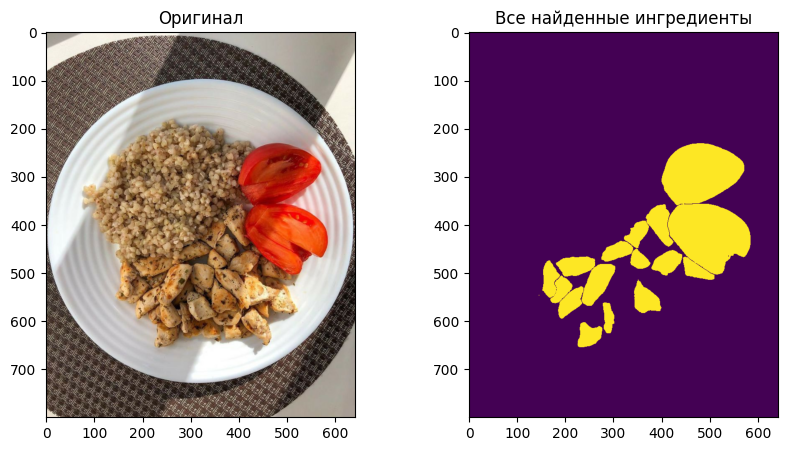

In [ ]:
total_meal = {'cal': 0, 'prot': 0, 'fat': 0, 'carb': 0, 'weight': 0}
detailed_report = []

for name, item in final_items.items():
    row = get_food_data(name)
    if row is not None:
        # Вспомогательная функция для чисел
        def f(key, default):
            col = [c for c in row.index if key in c.lower()]
            return float(str(row[col[0]]).replace(',', '.')) if col else default

        # Математика для конкретного куска
        item_weight = (item['area'] * sq_cm_per_pixel) * f('height', 2.0) * f('dens', 1.0)
        ratio = item_weight / 100

        c = f('cal', 0) * ratio
        p = f('prot', 0) * ratio
        j = f('fat', 0) * ratio
        u = f('carb', 0) * ratio

        # Добавляем в общую копилку
        total_meal['weight'] += item_weight
        total_meal['cal'] += c
        total_meal['prot'] += p
        total_meal['fat'] += j
        total_meal['carb'] += u

        print(f"📍 {name:25} | {item_weight:5.1f}г | {c:5.1f} ккал")
    else:
        print(f"⚠️ {name} не найден в базе данных")

print("—"*40)
print(f"ИТОГО ЗА ВЕСЬ ОБЕД:")
print(f"⚖️ Вес: {total_meal['weight']:.1f} г")
print(f"🔥 Энергия: {total_meal['cal']:.1f} ккал")
print(f"🧬 Б: {total_meal['prot']:.1f}г | Ж: {total_meal['fat']:.1f}г | У: {total_meal['carb']:.1f}г")
print("—"*40)

# Визуализация всех масок сразу
combined_mask = np.zeros_like(image[:,:,0])
for name, item in final_items.items():
    combined_mask[item['mask']] = 1

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(image); plt.title("Оригинал")
plt.subplot(1, 2, 2); plt.imshow(combined_mask); plt.title("Все найденные ингредиенты")
plt.show()